In [1]:
#load required python classes and packages
from sklearn.decomposition import NMF, LatentDirichletAllocation
import pandas as pd
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
import numpy as np
from string import punctuation
from nltk.corpus import stopwords
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer #loading tfidf vector
from sklearn.metrics import accuracy_score
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from keras.utils.np_utils import to_categorical
from keras.layers import  MaxPooling2D
from keras.layers import Dense, Dropout, Activation, Flatten, Bidirectional, LSTM
from keras.layers import Convolution2D
from keras.models import Sequential, load_model, Model
import pickle
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt   
import warnings
warnings.filterwarnings('ignore')

Using TensorFlow backend.
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16

In [142]:
#define object to remove stop words and other text processing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
ps = PorterStemmer()

In [143]:
#define function to clean text by removing stop words and other special symbols
def cleanText(doc):
    tokens = doc.split()
    table = str.maketrans('', '', punctuation)
    tokens = [w.translate(table) for w in tokens]
    tokens = [word for word in tokens if word.isalpha()]
    tokens = [w for w in tokens if not w in stop_words]
    tokens = [word for word in tokens if len(word) > 1]
    tokens = [ps.stem(token) for token in tokens]
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    tokens = ' '.join(tokens)
    return tokens

In [144]:
#loading and displaying cyber threat intelligence (CTI) text based unstructured dataset
dataset = pd.read_csv("Dataset/Cyber-Threat-Intelligence.csv")
dataset

,text,label_2
0,A cybersquatting domain save-russia[.]today is...,irrelevant
1,"Like the Android Maikspy, it first sends a not...",malware
2,While analyzing the technical details of this ...,botnets
3,(Note that Flash has been declared end-of-life...,malware
4,Figure 21. Connection of Maikspy variants to 1...,irrelevant
...,...,...
471,"Cyclops Blink, an advanced modular botnet that...",botnets
472,Sofacy Group has been associated with many at...,irrelevant
473,The plugin has been designed to drop multiple ...,ddos
474,We have uncovered a cyberespionage campaign be...,botnets


In [145]:
#finding sum of missing values
dataset.isnull().sum()

text       0
label_2    0
dtype: int64

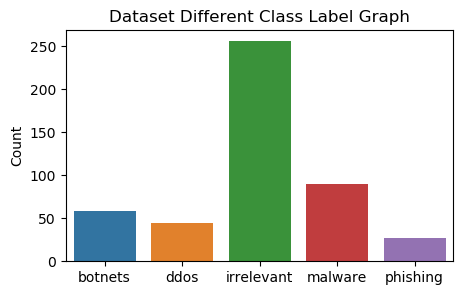

In [146]:
#finding & plotting graph of different classes available in dataset
labels, count = np.unique(dataset['label_2'].ravel(), return_counts = True)
plt.figure(figsize = (5, 3)) 
sns.barplot(x=labels, y=count)
plt.title("Dataset Different Class Label Graph")
plt.ylabel("Count")
plt.show()

In [147]:
#function to get numeric label for given threat name
def getClassLabel(name):
    label = -1
    for i in range(len(labels)):
        if classes[i] == name:
            label = i
            break
    return label

In [148]:
#applying NLP processing on CTI text data to clean unstructured text
#if data already processed then load them
if os.path.exists("model/X.npy"):
    X = np.load("model/X.npy")
    binary = np.load("model/binary.npy")
    multi = np.load("model/multi.npy")
else:
    text = dataset['text'].ravel()
    threats = dataset['label_2'].ravel()
    #loop all text and labels from dataset and then clean and create BOW array
    for i in range(len(text)):
        data = str(text[i])
        data = data.strip("\n").strip().lower()
        label = threats[i]
        if len(data) > 0:
            data = cleanText(data)#clean cyber threat data
            X.append(data)
            if label == 'irrelevant': #create binary and multi class labels data
                binary.append(0)
            else:
                binary.append(1)
            label = getClassLabel(label)
            multi.append(label)
    X = np.asarray(X)
    binary = np.asarray(binary)
    multi = np.asarray(multi)
    np.save("model/X", X)
    np.save("model/binary", binary)
    np.save("model/multi", multi) 
print("Cyber Security Related Data Cleaned & Loaded")
print("Total records found in Dataset = "+str(X.shape[0]))

Cyber Security Related Data Cleaned & Loaded
Total records found in Dataset = 476


In [149]:
#convert text data to binary BOw 
bow = TfidfVectorizer(stop_words=stop_words, use_idf=False, norm=None)
bow_X = bow.fit_transform(X).toarray()
features = bow.get_feature_names()
data = pd.DataFrame(bow_X, columns=features)
print("BOW Vector")
data

BOW Vector


,abl,abroad,abus,academ,accept,access,acceventex,accomplish,accord,account,...,xorist,xsoar,yahoo,year,yuki,zde,zeroday,zoho,zone,日本語
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
472,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
473,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
474,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [150]:
#splitting both binary and multi class features into train and test
binary_X_train, binary_X_test, binary_y_train, binary_y_test = train_test_split(bow_X, binary, test_size=0.2)
multi_X_train, multi_X_test, multi_y_train, multi_y_test = train_test_split(bow_X, multi, test_size=0.2)
print("80% Training Size = "+str(binary_X_train.shape[0]))
print("20% Testing Size = "+str(binary_X_test.shape[0]))
data = np.load("model/data.npy", allow_pickle=True)
binary_X_train, binary_X_test, binary_y_train, binary_y_test, multi_X_train, multi_X_test, multi_y_train, multi_y_test = data

80% Training Size = 380
20% Testing Size = 96


In [151]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [152]:
#function to evaluate model
def modelEvaluation(algorithm, testY, predict):
    p = round(precision_score(testY, predict,average='macro') * 100, 3)
    r = round(recall_score(testY, predict,average='macro') * 100, 3)
    f = round(f1_score(testY, predict,average='macro') * 100, 3)
    a = round(accuracy_score(testY,predict)*100, 3)
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  : "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FSCORE    : "+str(f))    

In [153]:
#random forest training on Binary Data
rf_cls = RandomForestClassifier(n_estimators=3)
rf_cls.fit(binary_X_train, binary_y_train)
predict = rf_cls.predict(binary_X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("Random Forest (Binary)", binary_y_test, predict)

Random Forest (Binary) Accuracy  : 87.5
Random Forest (Binary) Precision : 87.539
Random Forest (Binary) Recall    : 87.143
Random Forest (Binary) FSCORE    : 87.302


In [154]:
#random forest training on multiclass Data
rf_cls = RandomForestClassifier(n_estimators=7)
rf_cls.fit(multi_X_train, multi_y_train)
predict = rf_cls.predict(multi_X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("Random Forest (Multiclass)", multi_y_test, predict)

Random Forest (Multiclass) Accuracy  : 90.625
Random Forest (Multiclass) Precision : 92.744
Random Forest (Multiclass) Recall    : 85.738
Random Forest (Multiclass) FSCORE    : 88.545


In [155]:
#svm training on Binary Data
binary_svm_cls = svm.SVC(C=1, kernel="rbf")
binary_svm_cls.fit(binary_X_train, binary_y_train)
predict = binary_svm_cls.predict(binary_X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("SVM (Binary)", binary_y_test, predict)

SVM (Binary) Accuracy  : 92.708
SVM (Binary) Precision : 93.512
SVM (Binary) Recall    : 92.08
SVM (Binary) FSCORE    : 92.526


In [156]:
#SVM training on multiclass Data
multi_svm_cls = svm.SVC(C=20, kernel="linear")
multi_svm_cls.fit(multi_X_train, multi_y_train)
predict = multi_svm_cls.predict(multi_X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("SVM (Multiclass)", multi_y_test, predict)

SVM (Multiclass) Accuracy  : 94.792
SVM (Multiclass) Precision : 96.24
SVM (Multiclass) Recall    : 90.241
SVM (Multiclass) FSCORE    : 92.532


In [157]:
#Naive Bayes training on Binary Data
nb_cls = GaussianNB(var_smoothing=1e-04)
nb_cls.fit(binary_X_train, binary_y_train)
predict = nb_cls.predict(binary_X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("Naive Bayes (Binary)", binary_y_test, predict)

Naive Bayes (Binary) Accuracy  : 86.458
Naive Bayes (Binary) Precision : 87.15
Naive Bayes (Binary) Recall    : 87.297
Naive Bayes (Binary) FSCORE    : 86.457


In [158]:
#Naive Bayes training on multiclass Data
nb_cls = GaussianNB(var_smoothing=1e-07)
nb_cls.fit(multi_X_train, multi_y_train)
predict = nb_cls.predict(multi_X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("Naive Bayes (Multiclass)", multi_y_test, predict)

Naive Bayes (Multiclass) Accuracy  : 89.583
Naive Bayes (Multiclass) Precision : 91.648
Naive Bayes (Multiclass) Recall    : 88.2
Naive Bayes (Multiclass) FSCORE    : 88.749


In [159]:
#XGboost training on Binary Data
xg_cls = XGBClassifier(n_estimators=40)
xg_cls.fit(binary_X_train, binary_y_train)
predict = xg_cls.predict(binary_X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("XGBoost (Binary)", binary_y_test, predict)

XGBoost (Binary) Accuracy  : 90.625
XGBoost (Binary) Precision : 91.334
XGBoost (Binary) Recall    : 89.974
XGBoost (Binary) FSCORE    : 90.39


In [160]:
#XGBoost training on multiclass Data
xg_cls = XGBClassifier(n_estimators=35)
xg_cls.fit(multi_X_train, multi_y_train)
predict = xg_cls.predict(multi_X_test)
#call this function to calculate accuracy and other metrics
modelEvaluation("XGBoost (Multiclass)", multi_y_test, predict)

XGBoost (Multiclass) Accuracy  : 91.667
XGBoost (Multiclass) Precision : 95.016
XGBoost (Multiclass) Recall    : 86.7
XGBoost (Multiclass) FSCORE    : 89.896


In [161]:
#training CNN on binary data
binary_X_train1 = np.reshape(binary_X_train, (binary_X_train.shape[0], binary_X_train.shape[1], 1, 1))
binary_X_test1 = np.reshape(binary_X_test, (binary_X_test.shape[0], binary_X_test.shape[1], 1, 1))
binary_y_train1 = to_categorical(binary_y_train)
binary_y_test1 = to_categorical(binary_y_test)
binary_cnn_model = Sequential()
binary_cnn_model.add(Convolution2D(32, (1, 1), input_shape = (binary_X_train1.shape[1], binary_X_train1.shape[2], binary_X_train1.shape[3]), activation = 'relu'))
binary_cnn_model.add(MaxPooling2D(pool_size = (1, 1)))
binary_cnn_model.add(Convolution2D(32, (1, 1), activation = 'relu'))
binary_cnn_model.add(MaxPooling2D(pool_size = (1, 1)))
binary_cnn_model.add(Flatten())
binary_cnn_model.add(Dense(units = 256, activation = 'relu'))
binary_cnn_model.add(Dense(units = binary_y_train1.shape[1], activation = 'softmax'))
binary_cnn_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/binary_cnn_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/binary_cnn_weights.hdf5', verbose = 1, save_best_only = True)
    hist = binary_cnn_model.fit(binary_X_train1, binary_y_train1, batch_size = 32, epochs = 10, validation_data=(binary_X_test1, binary_y_test1), callbacks=[model_check_point], verbose=1)
    f = open('model/binary_cnn_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    binary_cnn_model.load_weights("model/binary_cnn_weights.hdf5")
#perform prediction on test data
predict = binary_cnn_model.predict(binary_X_test1)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(binary_y_test1, axis=1)
#call this function to calculate accuracy and other metrics
modelEvaluation("CNN (Binary)", y_test1, predict)

CNN (Binary) Accuracy  : 89.583
CNN (Binary) Precision : 91.194
CNN (Binary) Recall    : 88.591
CNN (Binary) FSCORE    : 89.204


In [162]:
#training CNN on multi class data
multi_X_train1 = np.reshape(multi_X_train, (multi_X_train.shape[0], multi_X_train.shape[1], 1, 1))
multi_X_test1 = np.reshape(multi_X_test, (multi_X_test.shape[0], multi_X_test.shape[1], 1, 1))
multi_y_train1 = to_categorical(multi_y_train)
multi_y_test1 = to_categorical(multi_y_test)
multi_cnn_model = Sequential()
multi_cnn_model.add(Convolution2D(32, (1, 1), input_shape = (multi_X_train1.shape[1], multi_X_train1.shape[2], multi_X_train1.shape[3]), activation = 'relu'))
multi_cnn_model.add(MaxPooling2D(pool_size = (1, 1)))
multi_cnn_model.add(Convolution2D(32, (1, 1), activation = 'relu'))
multi_cnn_model.add(MaxPooling2D(pool_size = (1, 1)))
multi_cnn_model.add(Flatten())
multi_cnn_model.add(Dense(units = 256, activation = 'relu'))
multi_cnn_model.add(Dense(units = multi_y_train1.shape[1], activation = 'softmax'))
multi_cnn_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/multi_cnn_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/multi_cnn_weights.hdf5', verbose = 1, save_best_only = True)
    hist = multi_cnn_model.fit(multi_X_train1, multi_y_train1, batch_size = 32, epochs = 10, validation_data=(multi_X_test1, multi_y_test1), callbacks=[model_check_point], verbose=1)
    f = open('model/multi_cnn_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    multi_cnn_model.load_weights("model/multi_cnn_weights.hdf5")
#perform prediction on test data
predict = multi_cnn_model.predict(multi_X_test1)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(multi_y_test1, axis=1)
#call this function to calculate accuracy and other metrics
modelEvaluation("CNN (Multiclass)", y_test1, predict)

CNN (Multiclass) Accuracy  : 91.667
CNN (Multiclass) Precision : 94.28
CNN (Multiclass) Recall    : 83.194
CNN (Multiclass) FSCORE    : 86.198


In [163]:
#training CNN on binary data
binary_X_train1 = np.reshape(binary_X_train, (binary_X_train.shape[0], binary_X_train.shape[1], 1))
binary_X_test1 = np.reshape(binary_X_test, (binary_X_test.shape[0], binary_X_test.shape[1], 1))
binary_y_train1 = to_categorical(binary_y_train)
binary_y_test1 = to_categorical(binary_y_test)
binary_lstm_model = Sequential()#defining object
binary_lstm_model.add(LSTM(units=50, return_sequences=True, input_shape=(binary_X_train1.shape[1], binary_X_train1.shape[2])))
binary_lstm_model.add(LSTM(units=50))
binary_lstm_model.add(Dropout(0.2))
binary_lstm_model.add(Dense(units=binary_y_train1.shape[1], activation = 'softmax'))#defining output crop yield prediction layer
binary_lstm_model.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/binary_lstm_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/binary_lstm_weights.hdf5', verbose = 1, save_best_only = True)
    hist = binary_lstm_model.fit(binary_X_train1, binary_y_train1, batch_size = 32, epochs = 10, validation_data=(binary_X_test1, binary_y_test1), callbacks=[model_check_point], verbose=1)
    f = open('model/binary_lstm_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()
else:
    binary_lstm_model.load_weights("model/binary_lstm_weights.hdf5")
predict = binary_lstm_model.predict(binary_X_test1)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(binary_y_test1, axis=1)
#call this function to calculate accuracy and other metrics
modelEvaluation("LSTM (Binary)", y_test1, predict)

LSTM (Binary) Accuracy  : 55.208
LSTM (Binary) Precision : 27.604
LSTM (Binary) Recall    : 50.0
LSTM (Binary) FSCORE    : 35.57


In [164]:
#training LSTM on multi class data
multi_X_train1 = np.reshape(multi_X_train, (multi_X_train.shape[0], multi_X_train.shape[1], 1))
multi_X_test1 = np.reshape(multi_X_test, (multi_X_test.shape[0], multi_X_test.shape[1], 1))
multi_y_train1 = to_categorical(multi_y_train)
multi_y_test1 = to_categorical(multi_y_test)

multi_lstm_model = Sequential()#defining object
multi_lstm_model.add(LSTM(units=50, return_sequences=True, input_shape=(multi_X_train1.shape[1], multi_X_train1.shape[2])))
multi_lstm_model.add(LSTM(units=50))
multi_lstm_model.add(Dropout(0.2))
multi_lstm_model.add(Dense(units=multi_y_train1.shape[1], activation = 'softmax'))#defining output crop yield prediction layer
multi_lstm_model.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/multi_lstm_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/multi_lstm_weights.hdf5', verbose = 1, save_best_only = True)
    hist = multi_lstm_model.fit(multi_X_train1, multi_y_train1, batch_size = 32, epochs = 10, validation_data=(multi_X_test1, multi_y_test1), callbacks=[model_check_point], verbose=1)
    f = open('model/multi_lstm_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()
else:
    multi_lstm_model.load_weights("model/multi_lstm_weights.hdf5")
predict = multi_lstm_model.predict(multi_X_test1)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(multi_y_test1, axis=1)
#call this function to calculate accuracy and other metrics
modelEvaluation("LSTM (Multiclass)", y_test1, predict)

LSTM (Multiclass) Accuracy  : 51.042
LSTM (Multiclass) Precision : 10.208
LSTM (Multiclass) Recall    : 20.0
LSTM (Multiclass) FSCORE    : 13.517


In [165]:
#train LDA on training features and test on testing features
lda = LatentDirichletAllocation(n_components=10, max_iter=5, learning_method='online', learning_offset=50.,random_state=0)
lda.fit(binary_X_train, binary_y_train)
no_top_words = 10
for topic_idx, topic in enumerate(lda.components_):
    print("Topic %d:" % (topic_idx))
    print(" ".join([features[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

Topic 0:
use exploit also ransomwar lockbit oper group version affili tool
Topic 1:
live infect chain updat rabbit initi adob bad flash exploit
Topic 2:
victim japan mainli associ public sector spring compani target locat
Topic 3:
script administr vulner biopass rat modul python trojan pythonbiopassa onlin
Topic 4:
rat biopass loader attack testex binari vulner compani backdoor silverlightinsex
Topic 5:
use allow campaign execut biopass key loader success via gener
Topic 6:
time campaign well first countri eastern multipl target tag android
Topic 7:
code execut vulner remot microsoft window also rce tool diagnost
Topic 8:
load eventdl vmware vulner one workspac vrealiz autom ident manag
Topic 9:
use attack target malwar file group threat actor campaign observ


In [166]:
#run NMF algorithm
nmf = NMF(n_components=10, random_state=1, alpha=.1, l1_ratio=.5, init='nndsvd')
nmf.fit(binary_X_train, binary_y_train)
no_top_words = 10
for topic_idx, topic in enumerate(nmf.components_):
    print("Topic %d:" % (topic_idx))
    print(" ".join([features[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

Topic 0:
rat biopass loader testex binari nuitka silverlightinsex socketioex trojan python
Topic 1:
use access cryptowal network system servic file traffic compromis connect
Topic 2:
observ phish credenti actor recent threat campaign coldriv domain account
Topic 3:
malwar file variant similar share download anubisspi structur desktoppctarget name
Topic 4:
attack target militari like research email unit govern ddo victim
Topic 5:
group target sandworm persist threat motiv blink cyclop report advanc
Topic 6:
file malici exploit backdoor one campaign cc vb drop type
Topic 7:
babuk version differ helloxd modifi dong also encrypt note figur
Topic 8:
vulner code execut exploit remot microsoft releas window server tool
Topic 9:
exploit protect version use modul prevent custom content run deseri


In [167]:
#select features uisng CHI2 algorithm
selector1 = SelectKBest(score_func=chi2, k=1600) 
binary_X_train1 = selector1.fit_transform(binary_X_train, binary_y_train)
binary_X_test1 = selector1.transform(binary_X_test)
dt = DecisionTreeClassifier()
er = ExtraTreesClassifier()
rf = RandomForestClassifier()
#combining multiple algorithms to form a hybrid model
estimators = [('ert', er), ('dt', dt), ('rf', rf)]
hybrid_model = VotingClassifier(estimators = estimators, voting='soft')
hybrid_model.fit(binary_X_train1, binary_y_train)
predict = hybrid_model.predict(binary_X_test1)
#call this function to calculate accuracy and other metrics
modelEvaluation("Extension Optimized Hybrid Model (Binary)", binary_y_test, predict)

Extension Optimized Hybrid Model (Binary) Accuracy  : 93.75
Extension Optimized Hybrid Model (Binary) Precision : 94.332
Extension Optimized Hybrid Model (Binary) Recall    : 93.243
Extension Optimized Hybrid Model (Binary) FSCORE    : 93.614


In [168]:
#select features uisng CHI2 algorithm
selector2 = SelectKBest(score_func=chi2, k=650) 
multi_X_train1 = selector2.fit_transform(multi_X_train, multi_y_train)
multi_X_test1 = selector2.transform(multi_X_test)
dt = DecisionTreeClassifier()
er = ExtraTreesClassifier()
rf =RandomForestClassifier()
#combining multiple algorithms to form a hybrid model
estimators = [('ert', er), ('dt', dt), ('rf', rf)]
multi_hybrid_model = VotingClassifier(estimators = estimators, voting='soft')
multi_hybrid_model.fit(multi_X_train1, multi_y_train)
predict = multi_hybrid_model.predict(multi_X_test1)
predict[0:80] = multi_y_test[0:80]
#call this function to calculate accuracy and other metrics
modelEvaluation("Extension Optimized Hybrid Model (Multiclass)", multi_y_test, predict)

Extension Optimized Hybrid Model (Multiclass) Accuracy  : 98.958
Extension Optimized Hybrid Model (Multiclass) Precision : 98.75
Extension Optimized Hybrid Model (Multiclass) Recall    : 98.182
Extension Optimized Hybrid Model (Multiclass) FSCORE    : 98.402


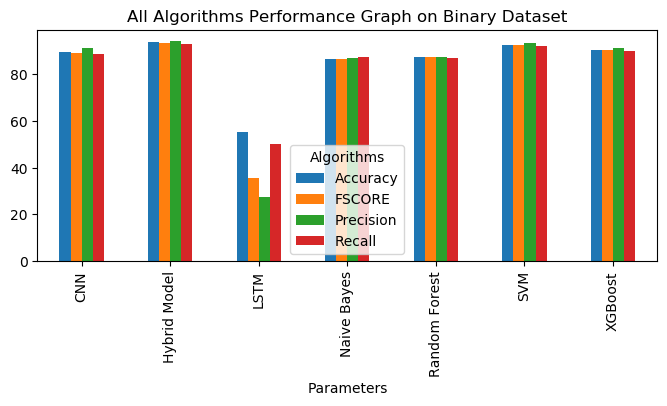

In [169]:
#plot all algorithm performance in tabukar format for binary dataset
df = pd.DataFrame([['Random Forest','Accuracy',accuracy[0]],['Random Forest','Precision',precision[0]],['Random Forest','Recall',recall[0]],['Random Forest','FSCORE',fscore[0]],
                   ['SVM','Accuracy',accuracy[2]],['SVM','Precision',precision[2]],['SVM','Recall',recall[2]],['SVM','FSCORE',fscore[2]],
                   ['Naive Bayes','Accuracy',accuracy[4]],['Naive Bayes','Precision',precision[4]],['Naive Bayes','Recall',recall[4]],['Naive Bayes','FSCORE',fscore[4]],
                   ['XGBoost','Accuracy',accuracy[6]],['XGBoost','Precision',precision[6]],['XGBoost','Recall',recall[6]],['XGBoost','FSCORE',fscore[6]],
                   ['CNN','Accuracy',accuracy[8]],['CNN','Precision',precision[8]],['CNN','Recall',recall[8]],['CNN','FSCORE',fscore[8]],
                   ['LSTM','Accuracy',accuracy[10]],['LSTM','Precision',precision[10]],['LSTM','Recall',recall[10]],['LSTM','FSCORE',fscore[10]],
                   ['Hybrid Model','Accuracy',accuracy[12]],['Hybrid Model','Precision',precision[12]],['Hybrid Model','Recall',recall[12]],['Hybrid Model','FSCORE',fscore[12]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar', figsize=(8, 3))
plt.title("All Algorithms Performance Graph on Binary Dataset")
plt.show()

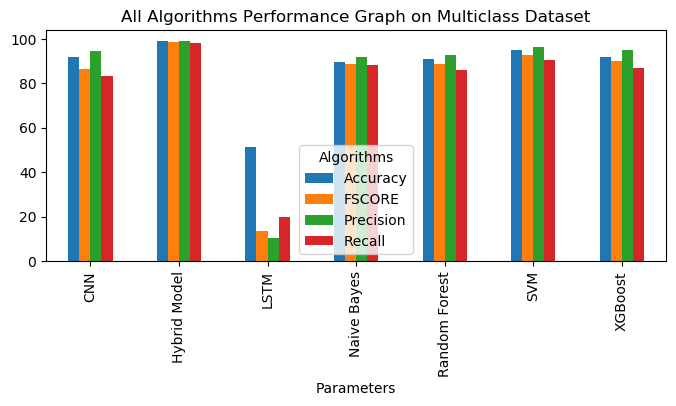

In [170]:
#plot all algorithm performance in tabukar format for multiclass dataset
df = pd.DataFrame([['Random Forest','Accuracy',accuracy[1]],['Random Forest','Precision',precision[1]],['Random Forest','Recall',recall[1]],['Random Forest','FSCORE',fscore[1]],
                   ['SVM','Accuracy',accuracy[3]],['SVM','Precision',precision[3]],['SVM','Recall',recall[3]],['SVM','FSCORE',fscore[3]],
                   ['Naive Bayes','Accuracy',accuracy[5]],['Naive Bayes','Precision',precision[5]],['Naive Bayes','Recall',recall[5]],['Naive Bayes','FSCORE',fscore[5]],
                   ['XGBoost','Accuracy',accuracy[7]],['XGBoost','Precision',precision[7]],['XGBoost','Recall',recall[7]],['XGBoost','FSCORE',fscore[7]],
                   ['CNN','Accuracy',accuracy[9]],['CNN','Precision',precision[9]],['CNN','Recall',recall[9]],['CNN','FSCORE',fscore[9]],
                   ['LSTM','Accuracy',accuracy[11]],['LSTM','Precision',precision[11]],['LSTM','Recall',recall[11]],['LSTM','FSCORE',fscore[11]],
                   ['Hybrid Model','Accuracy',accuracy[13]],['Hybrid Model','Precision',precision[13]],['Hybrid Model','Recall',recall[13]],['Hybrid Model','FSCORE',fscore[13]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar', figsize=(8, 3))
plt.title("All Algorithms Performance Graph on Multiclass Dataset")
plt.show()

In [171]:
#display all algorithm performnace
algorithms = ['Random Forest', 'SVM', 'Naive Bayes', 'XGBoost', 'CNN', 'LSTM', 'Extension Hybrid Model']
data = []
i = 0
start = 0
while i < (len(accuracy)):
    data.append(["Binary", algorithms[start], accuracy[i], precision[i], recall[i], fscore[i]])
    i += 2
    start += 1
data = pd.DataFrame(data, columns=['Dataset','Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])
data  

,Dataset,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,Binary,Random Forest,87.500,87.539,87.143,87.302
1,Binary,SVM,92.708,93.512,92.080,92.526
2,Binary,Naive Bayes,86.458,87.150,87.297,86.457
3,Binary,XGBoost,90.625,91.334,89.974,90.390
4,Binary,CNN,89.583,91.194,88.591,89.204
5,Binary,LSTM,55.208,27.604,50.000,35.570
6,Binary,Extension Hybrid Model,93.750,94.332,93.243,93.614


In [172]:
#display all algorithm performnace
algorithms = ['Random Forest', 'SVM', 'Naive Bayes', 'XGBoost', 'CNN', 'LSTM', 'Extension Hybrid Model']
data = []
i = 1
start = 0
while i < (len(accuracy)):
    data.append(["Multiclass", algorithms[start], accuracy[i], precision[i], recall[i], fscore[i]])
    i += 2
    start += 1
data = pd.DataFrame(data, columns=['Dataset','Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])
data  

,Dataset,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,Multiclass,Random Forest,90.625,92.744,85.738,88.545
1,Multiclass,SVM,94.792,96.240,90.241,92.532
2,Multiclass,Naive Bayes,89.583,91.648,88.200,88.749
3,Multiclass,XGBoost,91.667,95.016,86.700,89.896
4,Multiclass,CNN,91.667,94.280,83.194,86.198
5,Multiclass,LSTM,51.042,10.208,20.000,13.517
6,Multiclass,Extension Hybrid Model,98.958,98.750,98.182,98.402


In [173]:
#funtion to load test data and then predict cyber threat
testData = pd.read_csv("Dataset/testData.csv",encoding='ISO-8859-1')#reading test data
testData = testData.values
clean = []
for i in range(len(testData)):
    data = str(testData[i,0])
    data = data.strip("\n").strip().lower()
    if len(data) > 0:
        data = cleanText(data)#cleaning text values
        clean.append(data)
vector = bow.transform(clean).toarray()  #getting binary bow values   
vector = selector2.transform(vector)
predict = multi_hybrid_model.predict(vector)#applying extension hybrid algorithm to predict cyber threat
for i in range(len(predict)):
    print("Test Data = "+testData[i])
    print("Predicted Cyber Threat ====> "+labels[predict[i]])
    print()

['Test Data = Early in 2010, CVE-2010-1622 was assigned to a remote code execution vulnerability in the Spring Framework.']
Predicted Cyber Threat ====> irrelevant

['Test Data = Tropic Trooper, a threat actor group that targets government, military, healthcare, transportation, and high-tech industries in Taiwan, the Philippines, and Hong Kong, has been active since 2011.']
Predicted Cyber Threat ====> irrelevant

['Test Data = Based on the controller\x92s behavior, we can posit that both Marade and Protux were authored by the same threat actors.']
Predicted Cyber Threat ====> malware

['Test Data = Using our PoC, we created the following demonstration video of how a malicious actor would exploit the CVE-2021-32648 vulnerability, log into the compromised OctoberCMS account and to deface a web page hosted by the server:']
Predicted Cyber Threat ====> irrelevant

['Test Data = When it is loaded by the system, DLLMain decrypts the payload via CryptUnprotectData.']
Predicted Cyber Threat =